In [2]:
# ==============================================================================
# PROJETO 2: DETECÇÃO DE FRAUDE EM TRANSAÇÕES (PIX/CARTÃO)
# ETAPA 1: IMPORTAR FERRAMENTAS E GERAR DADOS DE TRANSAÇÕES
# ==============================================================================
import pandas as pd
import numpy as np

# Configurando a semente para gerar sempre os mesmos dados aleatórios
np.random.seed(42)

# Vamos simular um volume maior: 10.000 transações bancárias
n_transacoes = 10000

dados_transacoes = {
    'id_transacao': range(500001, 500001 + n_transacoes),
    # Simula o horário da transação (de 0h às 23h)
    'hora_transacao': np.random.randint(0, 24, size=n_transacoes),
    # Simula o valor enviado (de R$ 5,00 até R$ 20.000,00)
    'valor_transacao': np.random.uniform(5.0, 20000.0, size=n_transacoes).round(2),
    # Simula a idade do dono da conta (de 18 a 80 anos)
    'idade_cliente': np.random.randint(18, 81, size=n_transacoes),
    # Simula o limite diário pré-aprovado do cliente (R$ 1.000 a R$ 15.000)
    'limite_diario': np.random.randint(1000, 15001, size=n_transacoes)
}

df_fraude = pd.DataFrame(dados_transacoes)

# ------------------------------------------------------------------------------
# REGRA DE NEGÓCIO DA FRAUDE (CRIANDO O PADRÃO SUSPEITO)
# ------------------------------------------------------------------------------
# A chance de ser fraude aumenta muito se:
# 1. Acontecer de madrugada (entre 00h e 05h) E o valor for muito alto
# 2. O valor da transação estourar o limite diário do cliente
chance_fraude = np.zeros(n_transacoes)

# Condição 1: Madrugada perigosa
madrugada = (df_fraude['hora_transacao'] >= 0) & (df_fraude['hora_transacao'] <= 5)
chance_fraude[madrugada] += (df_fraude.loc[madrugada, 'valor_transacao'] / 20000.0) * 0.6

# Condição 2: Estouro de limite
estourou_limite = df_fraude['valor_transacao'] > df_fraude['limite_diario']
chance_fraude[estourou_limite] += 0.4

# Adiciona o ruído normal do mercado (falsos positivos, flutuações)
chance_fraude += np.random.normal(0, 0.1, n_transacoes)
chance_fraude = np.clip(chance_fraude, 0, 1)

# Se a chance calculada passar de 65% (0.65), carimbamos como FRAUDE (1). Se não, é NORMAL (0).
df_fraude['e_fraude'] = (chance_fraude > 0.65).astype(int)

# Salva a base em um novo arquivo CSV separado
df_fraude.to_csv('transacoes_seguras_e_fraudes.csv', index=False)

print("=== BASE DE SEGURANÇA BANCÁRIA GERADA ===")
print(f"Total de transações monitoradas: {len(df_fraude)}")
# Fraudes representam uma parte menor do total, igual ao mundo real (dados desbalanceados)
print(f"🚨 Total de fraudes confirmadas na base: {df_fraude['e_fraude'].sum()}")

=== BASE DE SEGURANÇA BANCÁRIA GERADA ===
Total de transações monitoradas: 10000
🚨 Total de fraudes confirmadas na base: 1245


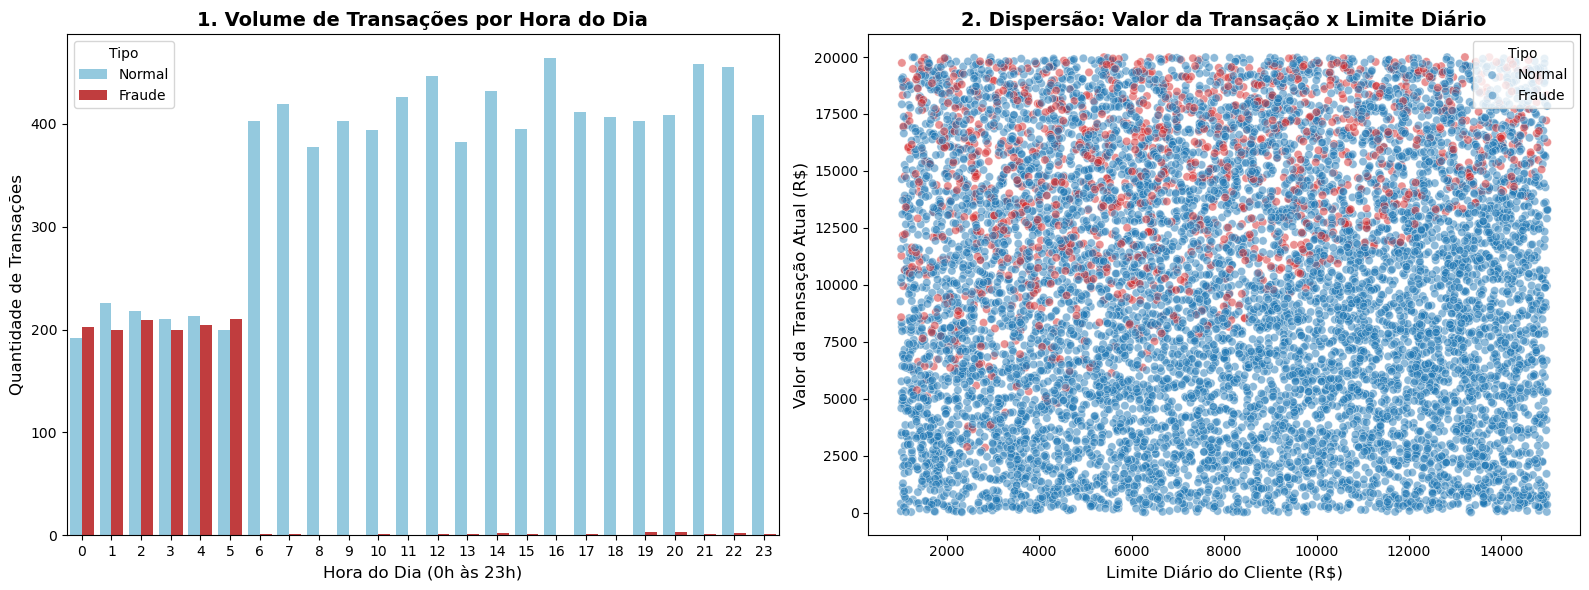

In [6]:
# ==============================================================================
# PROJETO 2: DETECÇÃO DE FRAUDE EM TRANSAÇÕES (PIX/CARTÃO)
# ETAPA 2: ANÁLISE VISUAL DOS PADRÕES DE GOLPE (EDA) - CORRIGIDO
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Carregamos o arquivo de transações que salvamos antes
df_fraude = pd.read_csv('transacoes_seguras_e_fraudes.csv')

# Configuramos a tela para exibir 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------------------
# GRÁFICO 1: Em quais horários acontecem as fraudes?
# ------------------------------------------------------------------------------
sns.countplot(
    x='hora_transacao', 
    hue='e_fraude', 
    data=df_fraude, 
    palette={0: 'skyblue', 1: '#d62728'}, 
    ax=axes[0]
)
axes[0].set_title('1. Volume de Transações por Hora do Dia', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hora do Dia (0h às 23h)', fontsize=12)
axes[0].set_ylabel('Quantidade de Transações', fontsize=12)
axes[0].legend(title='Tipo', labels=['Normal', 'Fraude'])

# ------------------------------------------------------------------------------
# GRÁFICO 2: O Golpe do Estouro de Limite (Valor x Limite Diário)
# ------------------------------------------------------------------------------
sns.scatterplot(
    x='limite_diario', 
    y='valor_transacao', 
    hue='e_fraude', 
    data=df_fraude, 
    palette={0: '#1f77b4', 1: '#d62728'}, 
    alpha=0.5, 
    ax=axes[1]
)
axes[1].set_title('2. Dispersão: Valor da Transação x Limite Diário', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Limite Diário do Cliente (R$)', fontsize=12)
axes[1].set_ylabel('Valor da Transação Atual (R$)', fontsize=12)
axes[1].legend(title='Tipo', labels=['Normal', 'Fraude'])

# Ajusta o layout para não cortar os textos
plt.tight_layout()

# Exibe os gráficos na tela
plt.show()

In [8]:
# ==============================================================================
# PROJETO 2: DETECÇÃO DE FRAUDE EM TRANSAÇÕES (PIX/CARTÃO)
# ETAPA 3: TREINAMENTO DA IA E ANÁLISE DE CRITÉRIOS DA FRAUDE
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# 1. SEPARAÇÃO: Separamos o ID da transação (que não serve para prever crime) e a resposta final
X = df_fraude.drop(columns=['id_transacao', 'e_fraude'])
y = df_fraude['e_fraude']

# 2. DIVISÃO: Separamos 80% das transações para treino e guardamos 20% para a prova real
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. TREINAMENTO: Inicializamos o modelo e fazemos ele estudar os dados históricos
modelo_fraude = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_fraude.fit(X_treino, y_treino)

# 4. PREVISÃO: A IA tenta adivinhar quais das transações do teste são golpes
previsoes_fraude = modelo_fraude.predict(X_teste)

# 5. RESULTADOS TÉCNICOS
acuracia = accuracy_score(y_teste, previsoes_fraude)

print("=== MODELO ANTIFRAUDE TREINADO COM SUCESSO! ===")
print(f"🎯 Acurácia Geral do Sistema: {acuracia * 100:.2f}%")
print("\nRelatório de Performance Técnico para o time de CyberSecurity:")
print(classification_report(y_teste, previsoes_fraude, target_names=['Transação Normal', 'Fraude Confirmada']))

# 6. ENGENHARIA REVERSA: Perguntamos para a IA o que ela achou mais importante para travar a transação
importancias = modelo_fraude.feature_importances_
recursos = X.columns

print("\n🔍 PESO DOS CRITÉRIOS NA TOMADA DE DECISÃO DA IA:")
for recurso, importancia in zip(recursos, importancias):
    print(f" - {recurso.upper()}: {importancia * 100:.2f}% de relevância")

=== MODELO ANTIFRAUDE TREINADO COM SUCESSO! ===
🎯 Acurácia Geral do Sistema: 97.75%

Relatório de Performance Técnico para o time de CyberSecurity:
                   precision    recall  f1-score   support

 Transação Normal       0.99      0.99      0.99      1752
Fraude Confirmada       0.92      0.90      0.91       248

         accuracy                           0.98      2000
        macro avg       0.95      0.94      0.95      2000
     weighted avg       0.98      0.98      0.98      2000


🔍 PESO DOS CRITÉRIOS NA TOMADA DE DECISÃO DA IA:
 - HORA_TRANSACAO: 52.58% de relevância
 - VALOR_TRANSACAO: 34.58% de relevância
 - IDADE_CLIENTE: 3.35% de relevância
 - LIMITE_DIARIO: 9.49% de relevância


In [10]:
# ==============================================================================
# PROJETO 2: DETECÇÃO DE FRAUDE EM TRANSAÇÕES (PIX/CARTÃO)
# ETAPA 4: CALCULAR O PREJUÍZO EVITADO PELO BLOQUEIO EM TEMPO REAL
# ==============================================================================
# Vamos fazer uma varredura para ver quantas fraudes o modelo acertou em cheio (Verdadeiros Positivos)
fraudes_bloqueadas = sum((y_teste == 1) & (previsoes_fraude == 1))

# Vamos calcular o valor real de cada uma dessas transações que a IA travou a tempo!
# Usamos o índice dos dados de teste para recuperar o valor exato na tabela original
valores_teste = df_fraude.loc[y_teste.index, 'valor_transacao']
total_salvo_fraude = valores_teste[(y_teste == 1) & (previsoes_fraude == 1)].sum()

print("=== RELATÓRIO DE MONITORAMENTO DE RISCO EM TEMPO REAL ===")
print(f"🚨 Tentativas de golpes detectadas no período de teste: {sum(y_teste == 1)}")
print(f"🛡️ Ataques bloqueados pelo sistema de IA: {fraudes_bloqueadas}")
print(f"💰 Volume financeiro que ia sair do banco e foi salvo: R$ {total_salvo_fraude:,.2f}".replace(",", "."))

=== RELATÓRIO DE MONITORAMENTO DE RISCO EM TEMPO REAL ===
🚨 Tentativas de golpes detectadas no período de teste: 248
🛡️ Ataques bloqueados pelo sistema de IA: 222
💰 Volume financeiro que ia sair do banco e foi salvo: R$ 3.378.786.18
